# Exercise 2

## Task 1

In [11]:
import pandas as pd

df = pd.DataFrame({'Sucess A':[112,261],
                   'Total A':[141,400],
                   'Sucess B':[323, 71],
                   'Total B':[410,115]})

In [12]:
df_prosent = pd.DataFrame()

df_prosent['Percentage Success A'] = round((df['Sucess A'] / df['Total A']) * 100, 1)
df_prosent['Percentage Success B'] = round((df['Sucess B'] / df['Total B']) * 100, 1)
print(df_prosent)

print(f"\nOverall success A: {round(df['Sucess A'].sum() / df['Total A'].sum() * 100, 1)}%,   Overall success B: {round(df['Sucess B'].sum() / df['Total B'].sum() * 100, 1)}%")

   Percentage Success A  Percentage Success B
0                  79.4                  78.8
1                  65.2                  61.7

Overall success A: 68.9%,   Overall success B: 75.0%


## Task 2

In [13]:
import pandas as pd

df_supernova = pd.read_csv("data/SN_list_large.csv",delimiter=',')
df_supernova.head()

,Date,Mag.,SN Position,Type
0,2015 02 07,19.1,09 09 35.06 +33 07 22.1,IIn
1,2015 12 16,17.8,02 47 34.51 +34 54 33.6,Ia
2,2015 12 12,17.3,23 24 49.03 +15 16 52.0,IIn
3,2015 12 06,18.0,05 14 06.24 -10 37 30.0,IIP
4,2015 12 07,15.9,11 23 45.88 -01 06 21.2,Ia


In [14]:
df_supernova.drop('SN Position',axis=1,inplace=True)
df_supernova.head()

,Date,Mag.,Type
0,2015 02 07,19.1,IIn
1,2015 12 16,17.8,Ia
2,2015 12 12,17.3,IIn
3,2015 12 06,18.0,IIP
4,2015 12 07,15.9,Ia


In [15]:
# Task 2.1
import random

simple_random_sample = random.choices(df_supernova['Mag.'].tolist(), k=100)
simple_random_sample[:5]

[18.0, 23.6, 18.5, 19.4, 22.6]

In [16]:
# Task 2.2

df_supernova['Date'] = pd.to_datetime(df_supernova['Date'])
df_supernova['year'] = df_supernova['Date'].dt.year
num_clusters = 5
samples_per_cluster = 20
clustered_samples = []
for cluster_id in range(num_clusters):
    cluster_data = df_supernova[(df_supernova['year'] >= 2000 + cluster_id * 2) & 
                               (df_supernova['year'] < 2000 + (cluster_id + 1) * 2)]
    cluster_samples = random.choices(cluster_data['Mag.'].tolist(), k=samples_per_cluster)
    clustered_samples.extend(cluster_samples)
    
clustered_samples[:5]

[19.4, 18.0, 18.7, 18.2, 18.0]

In [17]:
# Task 2.3 

relevant_types = ['Ia', 'II', 'IIn']

stratified_samples = []
for sn_type in relevant_types:
    type_data = df_supernova[df_supernova['Type'] == sn_type]
    type_samples = random.choices(type_data['Mag.'].tolist(), k=33)
    stratified_samples.extend(type_samples)
    
stratified_samples[:5]

[20.3, 19.7, 16.0, 18.8, 16.5]

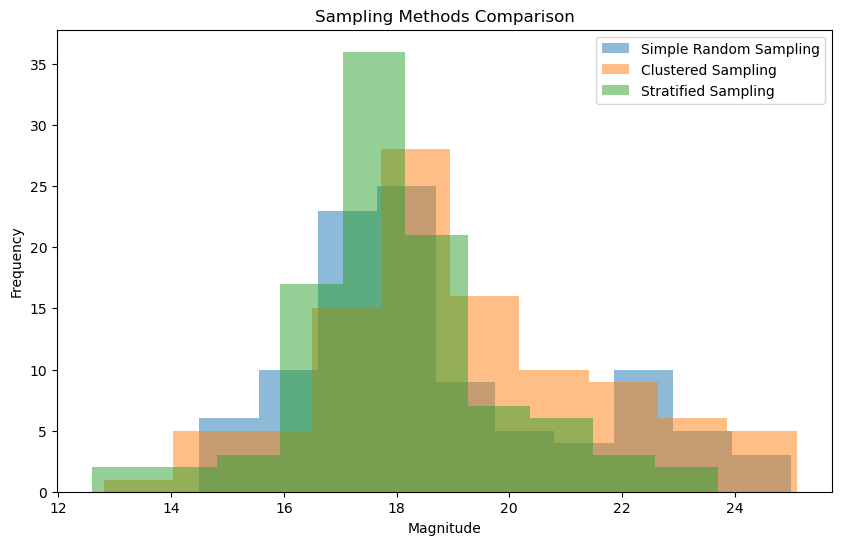

In [19]:
# Task 2.3.1 - Make a histogram 

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(simple_random_sample, bins=10, alpha=0.5, label='Simple Random Sampling')
plt.hist(clustered_samples, bins=10, alpha=0.5, label='Clustered Sampling')
plt.hist(stratified_samples, bins=10, alpha=0.5, label='Stratified Sampling')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.title('Sampling Methods Comparison')
plt.legend()
plt.show()